<a href="https://colab.research.google.com/github/shinitks/Airline_Reservation_system/blob/main/SignNet_SignatureForgeryDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install torch torchvision torchaudio matplotlib opencv-python scikit-learn

In [17]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"shinitks","key":"e74853a637d47cfd08ff9099047a2764"}'}

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d divyanshrai/handwritten-signatures
!unzip handwritten-signatures.zip -d /content/signature_data

Dataset URL: https://www.kaggle.com/datasets/divyanshrai/handwritten-signatures
License(s): unknown
handwritten-signatures.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  handwritten-signatures.zip
replace /content/signature_data/Dataset_Signature_Final/Dataset/dataset1/forge/02100001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import cv2, os
from sklearn.model_selection import train_test_split
from torch.utils.data import ConcatDataset

In [21]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset



# Training transform (with randomness)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((155, 220)),
    transforms.RandomRotation(3),
    transforms.RandomAffine(0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Testing transform (NO randomness)
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((155, 220)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print(torch.cuda.is_available())  # Check GPU



paths = [
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset1",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset2",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset3",
    "/content/signature_data/Dataset_Signature_Final/Dataset/dataset4"
]


datasets_list = [
    datasets.ImageFolder(root=p, transform=train_transform)
    for p in paths
]

dataset = ConcatDataset(datasets_list)


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])


test_data.dataset.transform = test_transform


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


True
Train samples: 576
Test samples: 144


In [22]:
import torch.nn as nn
import torch.nn.functional as F

class SignNet(nn.Module):
    def __init__(self):
        super(SignNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 19 * 27, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 2)  # 2 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        #print(x.shape)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = SignNet()
print(model)


SignNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65664, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Epoch [1/15], Loss: 0.7247
Epoch [2/15], Loss: 0.6946
Epoch [3/15], Loss: 0.6896
Epoch [4/15], Loss: 0.6354
Epoch [5/15], Loss: 0.5512
Epoch [6/15], Loss: 0.5017
Epoch [7/15], Loss: 0.4461
Epoch [8/15], Loss: 0.4041
Epoch [9/15], Loss: 0.3676
Epoch [10/15], Loss: 0.2701
Epoch [11/15], Loss: 0.1868
Epoch [12/15], Loss: 0.1674
Epoch [13/15], Loss: 0.1279
Epoch [14/15], Loss: 0.0644
Epoch [15/15], Loss: 0.0467


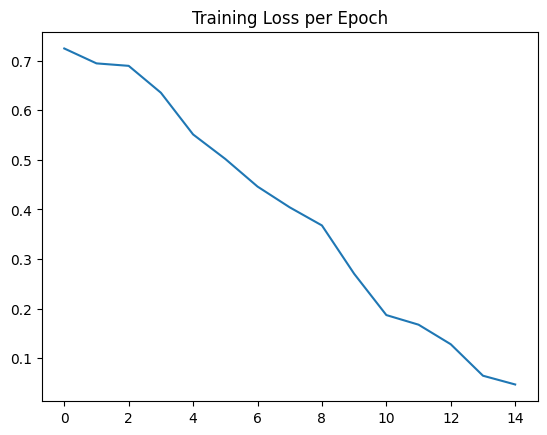

In [24]:
num_epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
train_losses = []


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    train_losses.append(running_loss / len(train_loader))

plt.plot(train_losses)
plt.title("Training Loss per Epoch")
plt.show()


In [26]:
#torch.save(model.state_dict(), "signnet_94acc.pth")


In [25]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")


Accuracy: 94.44%


In [28]:
model = SignNet().to(device)
model.load_state_dict(torch.load("signnet_94acc.pth", map_location=device))
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of loaded model: {accuracy:.2f}%")


Accuracy of loaded model: 94.44%
